# Fashion-MNIST Exploratory Data Analysis

This notebook examines the dataset structure, class distribution, representative samples, preprocessing, and train/validation/test split used in Assignment 1.

## 1. Dataset description

Fashion-MNIST is an image-classification dataset created by Zalando Research
as a more challenging drop-in replacement for the original MNIST dataset.

- **Source:** [Zalando Research Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist)
- **Original paper:** [Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms](https://arxiv.org/abs/1708.07747)
- **Dataset version:** The official dataset does not use a semantic version number; this project uses the dataset distributed through `torchvision.datasets.FashionMNIST`.
- **License:** MIT
- **Task:** Single-label, multiclass image classification
- **Official training samples:** 60,000
- **Official test samples:** 10,000
- **Number of classes:** 10
- **Annotations:** Each image has one integer class label from 0 to 9.
- **Image format:** 28 × 28 grayscale images
- **Tensor representation:** `[1, 28, 28]` after `ToTensor()`
- **Pixel representation:** `torch.float32` values in the range `[0, 1]` after `ToTensor()`
- **Raw storage format:** Compressed IDX files compatible with the original MNIST format

### 1.1 Classes

0. T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

### 1.2 Collection and labeling

The images originate from Zalando fashion articles. The official documentation
provides the class labels and dataset structure, but does not give enough
detail to independently evaluate the complete human-labeling procedure.
Therefore, labeling consistency must be treated as a possible limitation.

### 1.3 Biases and limitations

- The images contain only ten broad clothing categories.
- Images are grayscale and only 28 × 28 pixels, so color, texture, and fine
  visual details are unavailable.
- The dataset represents Zalando fashion articles and may not represent all
  clothing styles, cultures, brands, or real-world photographs.
- Several upper-body classes, particularly shirt, T-shirt/top, pullover, and
  coat, have similar silhouettes and may be difficult to distinguish.
- Each image has exactly one label, so multilabel clothing combinations are
  not represented.
- The centered product-image format differs from photographs containing
  people, backgrounds, occlusion, or multiple objects.

## 2. Setup and data loading

In [1]:
from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataloader import create_dataloaders
from src.data.dataset import get_fashion_mnist_datasets
from src.data.pipeline import create_normalized_datasets
from src.data.split import create_train_val_split
from src.data.transforms import (
    get_test_transforms,
    get_train_transforms,
    get_val_transforms,
)
from src.utils.seed import set_seed

SEED = 42
VALIDATION_SIZE = 0.1
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "fashion-mnist"

set_seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATA_DIR}")
print(f"Random seed: {SEED}")

Project root: C:\DeepLearning\CO3133-261-GroupXX\assignment1
Dataset directory: C:\DeepLearning\CO3133-261-GroupXX\assignment1\data\raw\fashion-mnist
Random seed: 42


In [2]:
train_dataset, _, test_dataset = (
    get_fashion_mnist_datasets(
        data_dir=DATA_DIR,
        train_transforms=get_train_transforms(),
        val_transforms=get_val_transforms(),
        test_transforms=get_test_transforms(),
    )
)

print(f"Official training dataset: {len(train_dataset):,}")
print(f"Official test dataset: {len(test_dataset):,}")

Official training dataset: 60,000
Official test dataset: 10,000


## 3. Raw-data exploratory analysis

### 3.1 Input properties

In [3]:
image, label = train_dataset[0]

print(f"Image shape: {tuple(image.shape)}")
print(f"Image dtype: {image.dtype}")
print(f"Minimum pixel value: {image.min().item():.3f}")
print(f"Maximum pixel value: {image.max().item():.3f}")
print(f"Label ID: {label}")
print(f"Class name: {train_dataset.classes[label]}")


Image shape: (1, 28, 28)
Image dtype: torch.float32
Minimum pixel value: 0.000
Maximum pixel value: 1.000
Label ID: 9
Class name: Ankle boot


### 3.2 Class distribution and imbalance

Largest class count: 6,000
Smallest class count: 6,000
Imbalance ratio: 1.00
0: T-shirt/top  6,000
1: Trouser      6,000
2: Pullover     6,000
3: Dress        6,000
4: Coat         6,000
5: Sandal       6,000
6: Shirt        6,000
7: Sneaker      6,000
8: Bag          6,000
9: Ankle boot   6,000


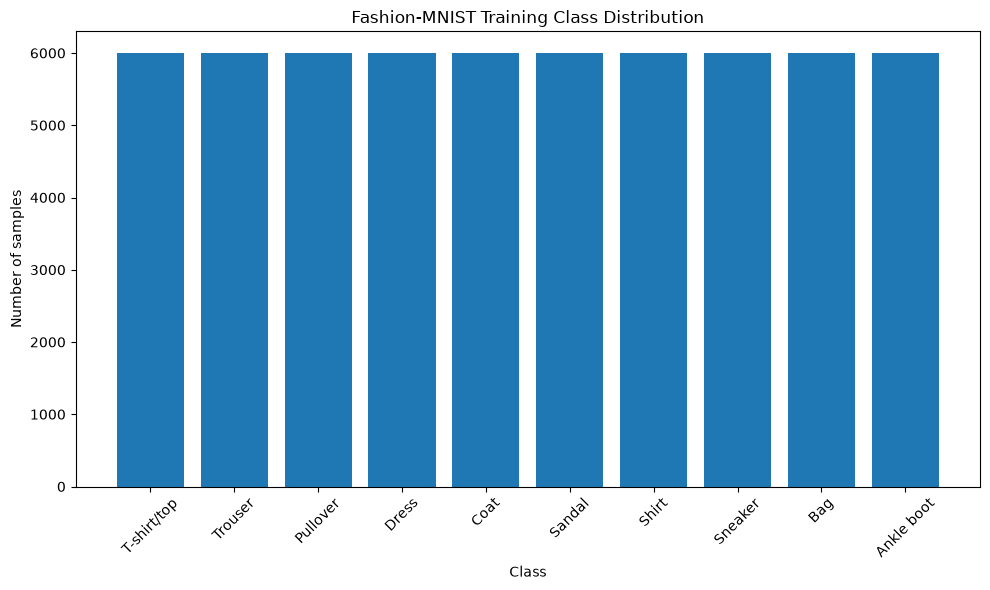

In [4]:
class_names = train_dataset.classes
class_counts = torch.bincount(
    train_dataset.targets,
    minlength=len(class_names),
)

largest_class = class_counts.max().item()
smallest_class = class_counts.min().item()
imbalance_ratio = largest_class / smallest_class

print(f"Largest class count: {largest_class:,}")
print(f"Smallest class count: {smallest_class:,}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

for class_id, (class_name, count) in enumerate(
    zip(class_names, class_counts)
):
    print(f"{class_id}: {class_name:<12} {count.item():,}")

plt.figure(figsize=(10, 6))
plt.bar(class_names, class_counts.numpy())
plt.title("Fashion-MNIST Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.2.1 Imbalance analysis

The official Fashion-MNIST training dataset is balanced. Each of the 10 classes contains 6,000 samples, producing an imbalance ratio of 1.00. Therefore, class weighting or over/undersampling is not required for the official training dataset.

### 3.3 Representative samples

The following figure displays one example from each Fashion-MNIST class.

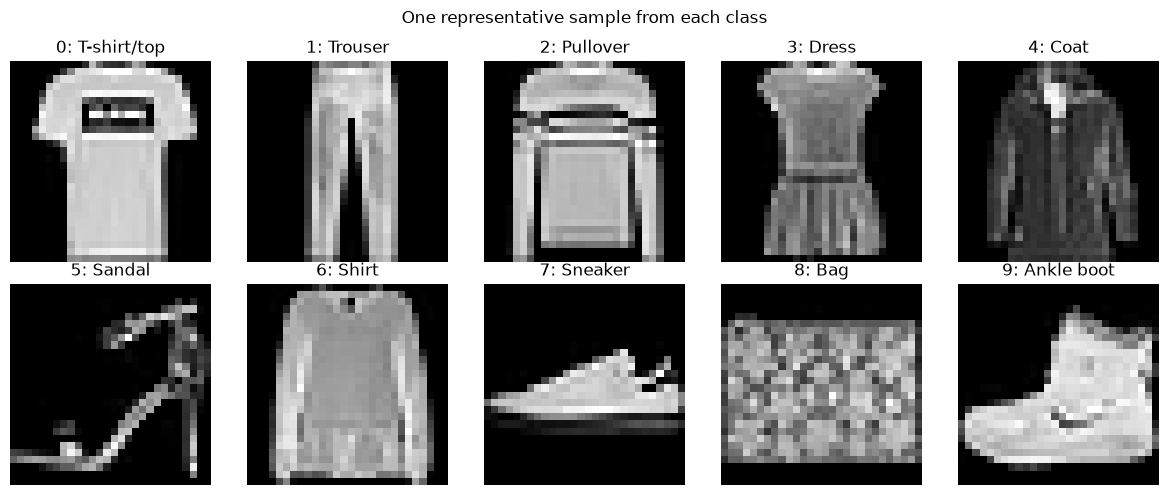

In [5]:
class_names = train_dataset.classes
representative_indices = []

for class_id in range(len(class_names)):
    class_index = (train_dataset.targets == class_id).nonzero()[0].item()
    representative_indices.append(class_index)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_id, (axis, sample_index) in enumerate(
    zip(axes.flat, representative_indices)
):
    image, label = train_dataset[sample_index]

    axis.imshow(image.squeeze(0), cmap="gray")
    axis.set_title(f"{label}: {class_names[label]}")
    axis.axis("off")

plt.suptitle("One representative sample from each class")
plt.tight_layout()
plt.show()

#### 3.3.1 Observations

Each class is represented by a 28x28 grayscale image. The objects are generally centered against a dark background. Some classes have clearly different outlines, such as trousers and bags, while visually similar classes such as shirts, T-shirts/tops, pullovers, and coats may be harder for a model to distinguish.

The low resolution removes fine texture and detail. Consequently, models must rely heavily on shape, edges, and spatial structure.

## 4. Data splitting

The official 60,000-image training dataset is divided into training and
validation subsets. The official 10,000-image test dataset remains untouched
and is used only for final evaluation.

The split uses individual images as the split unit, a fixed random seed of 42,
and stratification to preserve the class distribution.

In [6]:
train_indices, val_indices = create_train_val_split(
    labels=train_dataset.targets,
    validation_size=VALIDATION_SIZE,
    seed=SEED,
)

train_index_set = set(train_indices)
val_index_set = set(val_indices)

overlap = train_index_set.intersection(val_index_set)
covered_samples = train_index_set.union(val_index_set)

print(f"Training samples:         {len(train_indices):,}")
print(f"Validation samples:       {len(val_indices):,}")
print(f"Test samples:             {len(test_dataset):,}")
print(f"Train/validation overlap: {len(overlap):,}")
print(f"Original samples covered: {len(covered_samples):,}")

assert len(train_indices) == 54_000
assert len(val_indices) == 6_000
assert len(overlap) == 0
assert len(covered_samples) == 60_000

Training samples:         54,000
Validation samples:       6,000
Test samples:             10,000
Train/validation overlap: 0
Original samples covered: 60,000


In [7]:
train_labels = train_dataset.targets[
    torch.as_tensor(train_indices, dtype=torch.long)
]
val_labels = train_dataset.targets[
    torch.as_tensor(val_indices, dtype=torch.long)
]
test_labels = test_dataset.targets

train_split_counts = torch.bincount(train_labels, minlength=10)
val_split_counts = torch.bincount(val_labels, minlength=10)
test_split_counts = torch.bincount(test_labels, minlength=10)

print(
    f"{'Class':<15}"
    f"{'Train':>10}"
    f"{'Validation':>14}"
    f"{'Test':>10}"
)

for class_id, class_name in enumerate(class_names):
    print(
        f"{class_name:<15}"
        f"{train_split_counts[class_id].item():>10,}"
        f"{val_split_counts[class_id].item():>14,}"
        f"{test_split_counts[class_id].item():>10,}"
    )

Class               Train    Validation      Test
T-shirt/top         5,400           600     1,000
Trouser             5,400           600     1,000
Pullover            5,400           600     1,000
Dress               5,400           600     1,000
Coat                5,400           600     1,000
Sandal              5,400           600     1,000
Shirt               5,400           600     1,000
Sneaker             5,400           600     1,000
Bag                 5,400           600     1,000
Ankle boot          5,400           600     1,000


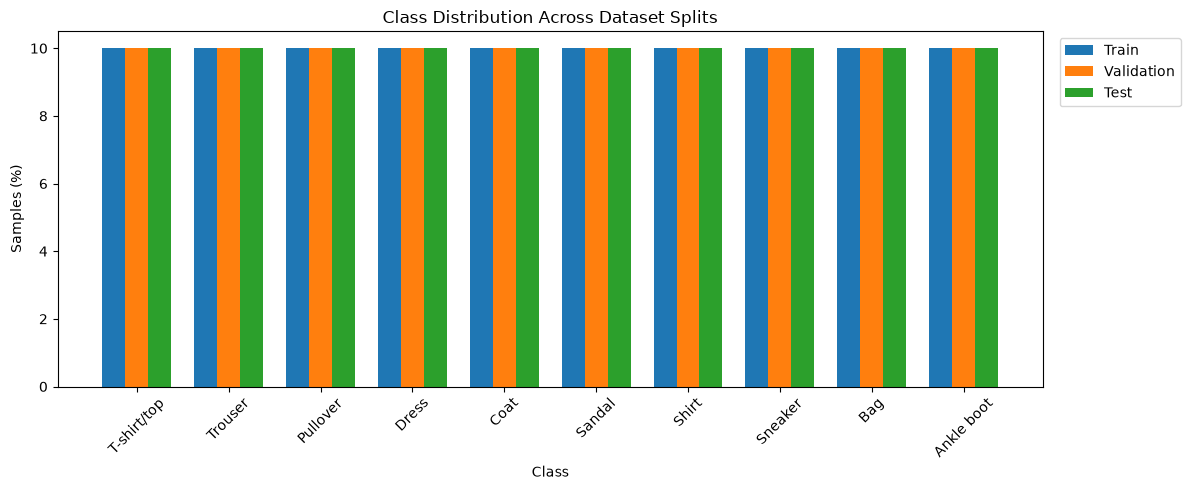

In [8]:
train_percentages = train_split_counts.numpy() / len(train_indices) * 100
val_percentages = val_split_counts.numpy() / len(val_indices) * 100
test_percentages = test_split_counts.numpy() / len(test_dataset) * 100

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, train_percentages, width, label="Train")
plt.bar(x, val_percentages, width, label="Validation")
plt.bar(x + width, test_percentages, width, label="Test")

plt.xticks(x, class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Samples (%)")
plt.title("Class Distribution Across Dataset Splits")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [9]:
def calculate_imbalance_ratio(counts):
    return counts.max().item() / counts.min().item()

print("Training imbalance ratio: "
      f"{calculate_imbalance_ratio(train_split_counts):.2f}"
    )
print("Validation imbalance ratio: "
      f"{calculate_imbalance_ratio(val_split_counts):.2f}"
    )
print("Test imbalance ratio: "
      f"{calculate_imbalance_ratio(test_split_counts):.2f}"
    )

Training imbalance ratio: 1.00
Validation imbalance ratio: 1.00
Test imbalance ratio: 1.00


### 4.1 Split analysis

Stratification preserved the class distribution during the train/validation
split. Every class represents 10% of the training, validation, and test sets.
Each split has an imbalance ratio of 1.00, so no class weighting,
oversampling, or undersampling is required.

The fixed seed makes the custom split reproducible, while the absence of
overlapping train and validation indices prevents direct sample leakage.
The official test set remains separate and is reserved for final evaluation.

## 5. Preprocessing

Images are converted from unsigned 8-bit pixel values in `[0, 255]` to
`torch.float32` tensors in `[0, 1]` using `ToTensor()`.

The channel mean and standard deviation are calculated using only the custom
training subset. The same statistics are then used to normalize the training,
validation, and test datasets. Validation and test data do not influence the
normalization parameters.

### 5.1 Training-only normalization

In [10]:
(
    normalized_train_dataset,
    normalized_val_dataset,
    normalized_test_dataset,
    train_mean,
    train_std,
) = create_normalized_datasets(
    data_dir=DATA_DIR,
    validation_size=VALIDATION_SIZE,
    seed=SEED,
)

print(f"Training samples:   {len(normalized_train_dataset):,}")
print(f"Validation samples: {len(normalized_val_dataset):,}")
print(f"Test samples:       {len(normalized_test_dataset):,}")
print(f"Training mean:      {train_mean:.6f}")
print(f"Training std:       {train_std:.6f}")

Training samples:   54,000
Validation samples: 6,000
Test samples:       10,000
Training mean:      0.286209
Training std:       0.353160


In [11]:
normalized_image, normalized_label = normalized_train_dataset[0]

print(f"Image shape: {tuple(normalized_image.shape)}")
print(f"Image dtype: {normalized_image.dtype}")
print(f"Minimum pixel value: {normalized_image.min().item():.3f}")
print(f"Maximum pixel value: {normalized_image.max().item():.3f}")
print(f"Label ID: {normalized_label}")

assert len(normalized_train_dataset) == 54_000
assert len(normalized_val_dataset) == 6_000
assert len(normalized_test_dataset) == 10_000
assert normalized_image.shape == (1, 28, 28)
assert normalized_image.dtype == torch.float32
assert train_std > 0

Image shape: (1, 28, 28)
Image dtype: torch.float32
Minimum pixel value: -0.810
Maximum pixel value: 2.021
Label ID: 8


### 5.2 Example batch after preprocessing

The datasets are wrapped in DataLoaders that combine individual samples into
batches. Training data is shuffled, while validation and test data retain a
fixed order.

In [12]:
BATCH_SIZE = 64
NUM_WORKERS = 0

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset=normalized_train_dataset,
    val_dataset=normalized_val_dataset,
    test_dataset=normalized_test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

torch.manual_seed(SEED)
batch_images, batch_labels = next(iter(train_loader))

print(f"Image batch shape: {tuple(batch_images.shape)}")
print(f"Label batch shape: {tuple(batch_labels.shape)}")
print(f"Image dtype: {batch_images.dtype}")
print(f"Label dtype: {batch_labels.dtype}")
print(f"Minimum pixel value: {batch_images.min().item():.3f}")
print(f"Maximum pixel value: {batch_images.max().item():.3f}")
print(f"Batch mean: {batch_images.mean().item():.3f}")
print(f"Batch standard deviation: {batch_images.std().item():.3f}")
print(f"First 10 labels: {batch_labels[:10].tolist()}")

assert batch_images.shape == (BATCH_SIZE, 1, 28, 28)
assert batch_labels.shape == (BATCH_SIZE,)
assert batch_images.dtype == torch.float32
assert batch_labels.dtype == torch.int64
assert torch.isfinite(batch_images).all()
assert batch_labels.min() >= 0
assert batch_labels.max() < 10

Image batch shape: (64, 1, 28, 28)
Label batch shape: (64,)
Image dtype: torch.float32
Label dtype: torch.int64
Minimum pixel value: -0.810
Maximum pixel value: 2.021
Batch mean: 0.046
Batch standard deviation: 1.004
First 10 labels: [4, 6, 9, 2, 0, 2, 3, 6, 3, 5]


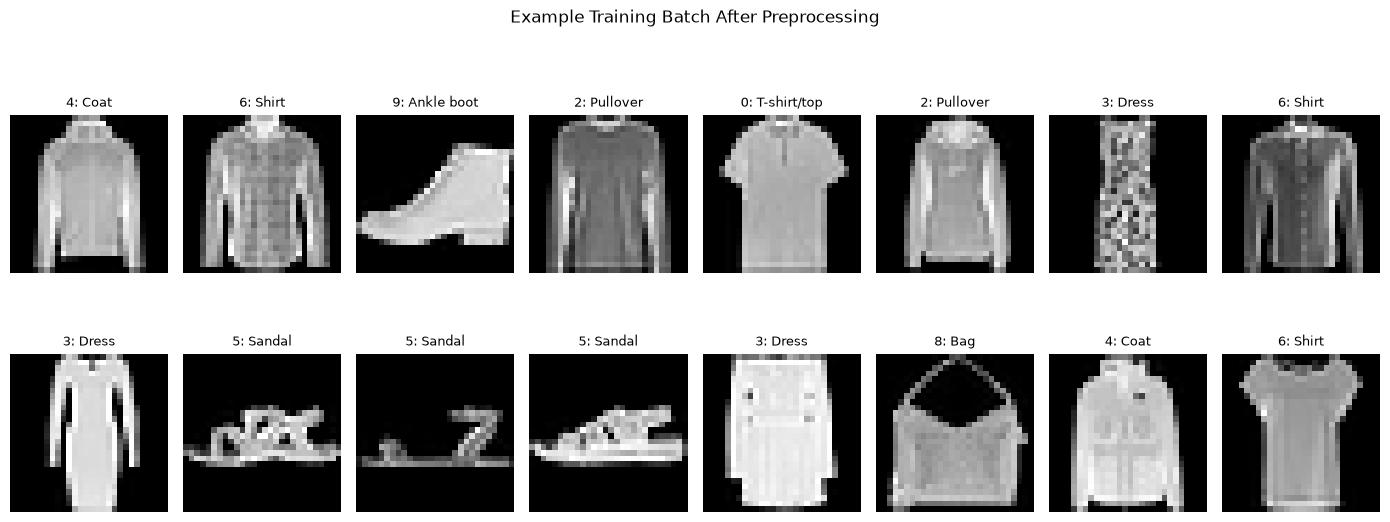

In [13]:
denormalized_images = (batch_images * train_std + train_mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 6))

for index, axis in enumerate(axes.flat):
    image = denormalized_images[index].squeeze(0)
    label = batch_labels[index].item()

    axis.imshow(image, cmap="gray", vmin=0, vmax=1)
    axis.set_title(f"{label}: {class_names[label]}", fontsize=9)
    axis.axis("off")

plt.suptitle("Example Training Batch After Preprocessing")
plt.tight_layout()
plt.show()

#### 5.2.1 Batch observations

The example batch has shape `[64, 1, 28, 28]`, representing 64 grayscale
images with one channel and a spatial resolution of 28 × 28. Its labels have
shape `[64]`, providing one integer class target for each image.

The normalized batch has a mean close to zero and a standard deviation close
to one. Minor differences are expected because these values describe one
random batch, while the normalization statistics were calculated from the
complete training subset.

The images were denormalized only for visualization. The models receive the
normalized tensors during training.

## 6. Data representation and inductive bias

An inductive bias is an assumption built into a model's architecture about
which patterns are likely to be useful. All models receive the same normalized
images, but they interpret the image structure differently.

In [14]:
model_batch = batch_images
batch_size = model_batch.shape[0]

# Linear and MLP: flatten every image into 784 pixel features.
flattened_pixels = model_batch.flatten(start_dim=1)

# CNN: preserve channel, height, and width dimensions.
spatial_images = model_batch

# RNN option 1: treat each image row as one sequence step.
row_sequences = model_batch.squeeze(1)

# RNN option 2: treat each image column as one sequence step.
column_sequences = model_batch.squeeze(1).transpose(1, 2)

# Transformer: divide each image into non-overlapping 4 x 4 patches.
patch_size = 4

patch_grid = model_batch.unfold(
    dimension=2,
    size=patch_size,
    step=patch_size,
).unfold(
    dimension=3,
    size=patch_size,
    step=patch_size,
)

patch_sequences = patch_grid.permute(0, 2, 3, 1, 4, 5).reshape(
    batch_size,
    -1,
    patch_size * patch_size,
)

print(f"Original batch:     {tuple(model_batch.shape)}")
print(f"Linear/MLP input:   {tuple(flattened_pixels.shape)}")
print(f"CNN input:          {tuple(spatial_images.shape)}")
print(f"RNN row sequence:   {tuple(row_sequences.shape)}")
print(f"RNN column sequence:{tuple(column_sequences.shape)}")
print(f"Transformer patches:{tuple(patch_sequences.shape)}")

assert flattened_pixels.shape == (BATCH_SIZE, 784)
assert spatial_images.shape == (BATCH_SIZE, 1, 28, 28)
assert row_sequences.shape == (BATCH_SIZE, 28, 28)
assert column_sequences.shape == (BATCH_SIZE, 28, 28)
assert patch_sequences.shape == (BATCH_SIZE, 49, 16)


Original batch:     (64, 1, 28, 28)
Linear/MLP input:   (64, 784)
CNN input:          (64, 1, 28, 28)
RNN row sequence:   (64, 28, 28)
RNN column sequence:(64, 28, 28)
Transformer patches:(64, 49, 16)


### 6.1 Linear and MLP representation

Linear and MLP models flatten each image from `[1, 28, 28]` into a vector of
784 pixel values. This representation is simple, but it discards the explicit
two-dimensional relationship between neighbouring pixels. These models must
learn spatial relationships entirely from the data.

### 6.2 CNN representation

A CNN preserves the `[1, 28, 28]` spatial structure. Convolutional filters
process neighbouring pixels together and reuse the same filters at different
image positions. This provides a useful inductive bias for detecting local
features such as edges, corners, and clothing outlines.

### 6.3 RNN representation

An RNN can interpret an image as a sequence of 28 rows, where every step
contains 28 pixel features. A column-based sequence is also possible. This
preserves ordering in one direction, but gives less direct access to
two-dimensional neighbourhoods than a CNN. The chosen scan direction may
therefore affect the patterns learned by the model.

### 6.4 Transformer representation

With 4 × 4 non-overlapping patches, a 28 × 28 image becomes a sequence of
49 patch tokens. Each token initially contains 16 pixel values before being
projected into the model's embedding dimension. Self-attention can model
relationships between distant patches, but it does not automatically know
their positions, so positional information must be added.

### 6.5 Comparison

The flattened representation makes the fewest structural assumptions. CNNs
assume that local spatial patterns are important. RNNs assume that the image
can be interpreted as an ordered row or column sequence. Transformers treat
the image as a sequence of patches and learn relationships between all patch
positions. These different inductive biases help explain why the models may
achieve different results even when trained on identical data splits.

## 7. Dataset storage

In [15]:
dataset_files = [path for path in DATA_DIR.rglob("*") if path.is_file()]

total_size_bytes = sum(path.stat().st_size for path in dataset_files)

total_size_mib = total_size_bytes / (1024 ** 2)

file_formats = Counter(path.suffix.lower() or "[no extension]" for path in dataset_files)

print(f"Dataset directory: {DATA_DIR}")
print(f"Number of files: {len(dataset_files)}")
print(f"Total local storage: {total_size_mib:.2f} MiB")

print("\nFiles:")
for path in sorted(dataset_files):
    relative_path = path.relative_to(DATA_DIR)
    size_mib = path.stat().st_size / (1024 ** 2)
    print(f"- {relative_path}: {size_mib:.2f} MiB")

print("\nFile extensions:")
for extension, count in sorted(file_formats.items()):
    print(f"- {extension}: {count}")

Dataset directory: C:\DeepLearning\CO3133-261-GroupXX\assignment1\data\raw\fashion-mnist
Number of files: 8
Total local storage: 81.85 MiB

Files:
- FashionMNIST\raw\t10k-images-idx3-ubyte: 7.48 MiB
- FashionMNIST\raw\t10k-images-idx3-ubyte.gz: 4.22 MiB
- FashionMNIST\raw\t10k-labels-idx1-ubyte: 0.01 MiB
- FashionMNIST\raw\t10k-labels-idx1-ubyte.gz: 0.00 MiB
- FashionMNIST\raw\train-images-idx3-ubyte: 44.86 MiB
- FashionMNIST\raw\train-images-idx3-ubyte.gz: 25.20 MiB
- FashionMNIST\raw\train-labels-idx1-ubyte: 0.06 MiB
- FashionMNIST\raw\train-labels-idx1-ubyte.gz: 0.03 MiB

File extensions:
- .gz: 4
- [no extension]: 4


## 8. EDA conclusion

Fashion-MNIST contains 70,000 labelled 28 × 28 grayscale images: 60,000 in
the official training dataset and 10,000 in the official test dataset. The
local dataset occupies approximately **81.85 MiB**, including files
downloaded and extracted by Torchvision.

The official training dataset is perfectly balanced, containing 6,000 samples
for each of the 10 classes. A stratified split with seed 42 produced 54,000
training samples and 6,000 validation samples. Each custom subset remains
balanced, and their index sets do not overlap. The official test set remains
separate for final evaluation.

Images are converted to `torch.float32` tensors with shape `[1, 28, 28]` and
initial pixel values in `[0, 1]`. Normalization statistics were calculated
only from the training subset, producing a mean of **0.286209** and a standard
deviation of **0.353160**. The same statistics are applied to training,
validation, and test images to prevent evaluation-data leakage.

A training DataLoader produces image batches with shape `[64, 1, 28, 28]`
and label batches with shape `[64]`. Training samples are shuffled, while
validation and test samples retain deterministic ordering.

Representative samples show that several upper-body categories, including
T-shirt/top, shirt, pullover, and coat, have similar low-resolution
silhouettes. These classes may be more difficult to distinguish than visually
different classes such as trousers, bags, and footwear.

The five model families apply different inductive biases. Linear and MLP
models use 784 flattened pixels, CNNs preserve two-dimensional spatial
structure, RNNs interpret rows or columns as sequences, and Transformers
represent images as sequences of patches. These representation choices may
lead to different performance even when all models use identical data splits
and evaluation procedures.